In [3]:
import pandas as pd

df = pd.read_csv("student_mental_health_dataset.csv")
df.head()

,sleep_hours,stress_level,study_hours,social_hours,mood_score,risk
0,5.9,3,2,5,2,1
1,8.1,10,3,1,10,1
2,6.4,9,4,3,1,1
3,7.0,3,9,2,4,1
4,7.7,6,5,2,10,0


In [4]:
df.describe()

,sleep_hours,stress_level,study_hours,social_hours,mood_score,risk
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.492400,5.644000,5.624000,2.794000,5.650000,0.536000
std,1.463101,2.872938,2.852876,2.024787,2.804145,0.499202
min,4.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,5.275000,3.000000,3.000000,1.000000,3.000000,0.000000
50%,6.500000,6.000000,6.000000,3.000000,6.000000,1.000000
75%,7.800000,8.000000,8.000000,5.000000,8.000000,1.000000
max,9.000000,10.000000,10.000000,6.000000,10.000000,1.000000


In [5]:
df['risk'].value_counts()

,count
risk,
1,268
0,232


In [6]:
from sklearn.model_selection import train_test_split

X = df[["sleep_hours", "stress_level", "study_hours", "social_hours", "mood_score"]]
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((400, 5), (100, 5))

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
acc_lr

0.8

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
acc_rf

0.98

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)
acc_dt

0.98

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, pred_knn)
acc_knn

0.82

In [11]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)
acc_svm

0.85

In [12]:
print("Logistic Regression:", acc_lr)
print("Random Forest:", acc_rf)
print("Decision Tree:", acc_dt)
print("KNN:", acc_knn)
print("SVM:", acc_svm)

Logistic Regression: 0.8
Random Forest: 0.98
Decision Tree: 0.98
KNN: 0.82
SVM: 0.85


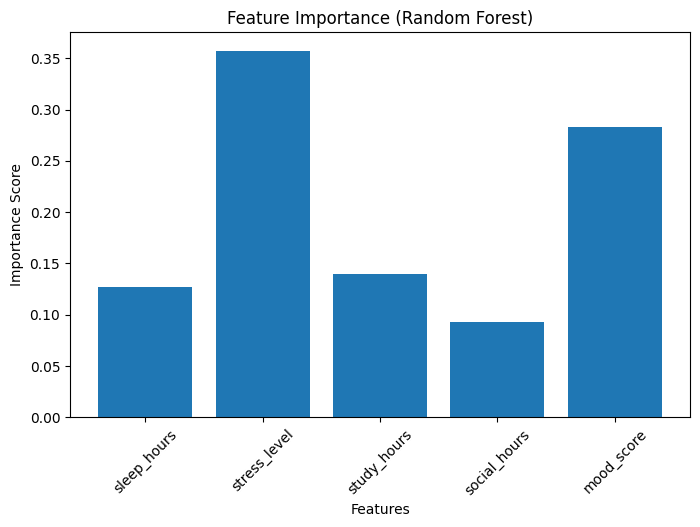

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the trained RandomForest model 'rf'
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

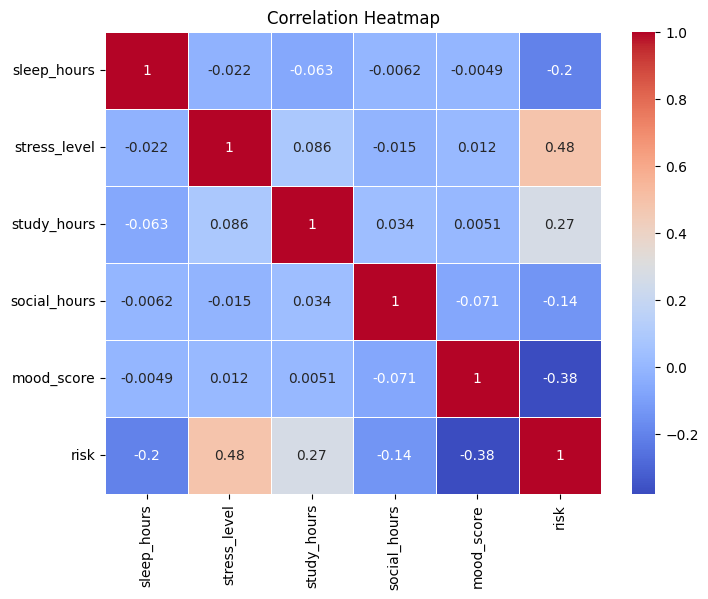

In [19]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

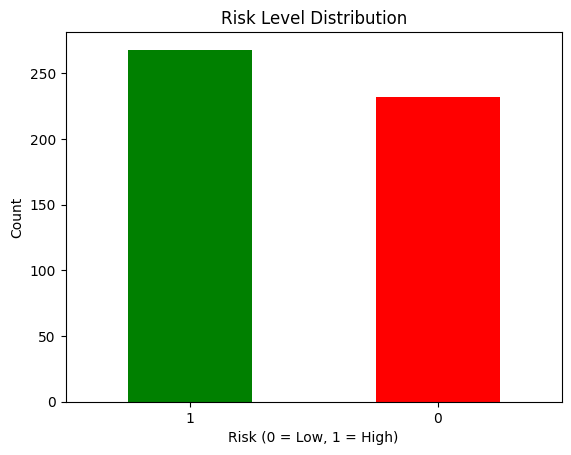

In [20]:
df['risk'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Risk Level Distribution")
plt.xlabel("Risk (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [15]:
import pandas as pd

def test_prediction(sleep, stress, study, social, mood):
    df_input = pd.DataFrame([{
        "sleep_hours": sleep,
        "stress_level": stress,
        "study_hours": study,
        "social_hours": social,
        "mood_score": mood
    }])

    pred = rf.predict(df_input)[0]

    if pred == 1:
        return f"High Risk ⚠ (sleep={sleep}, stress={stress}, study={study}, social={social}, mood={mood})"
    else:
        return f"Low Risk ✔ (sleep={sleep}, stress={stress}, study={study}, social={social}, mood={mood})"

In [23]:
sleep = float(input("Sleep hours: "))
stress = int(input("Stress (1–10): "))
study = int(input("Study hours: "))
social = int(input("Social hours: "))
mood = int(input("Mood (1–10): "))
3
print(test_prediction(sleep, stress, study, social, mood))

Sleep hours: 8
Stress (1–10): 5
Study hours: 5
Social hours: 5
Mood (1–10): 5
Low Risk ✔ (sleep=8.0, stress=5, study=5, social=5, mood=5)


In [24]:
import pickle

# Save model
with open("student_wellness_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model exported as student_wellness_model.pkl")

Model exported as student_wellness_model.pkl
